In [1]:
import matplotlib.pyplot as plt
import numpy as np
from signal_processing import peakfinder

import numpy as np
import matplotlib.pyplot as plt

def resp_plot(cleaned_signal, time, peaks, troughs, onset=None, end=None):
	# Create the plot
	plt.figure(figsize=(10, 6))

	# Plot cleaned signal
	plt.plot(time, cleaned_signal, color="blue", label="Cleaned Signal")

	# Plot inhalation peaks
	plt.scatter(time[peaks == 1], cleaned_signal[peaks == 1], 
				color="red", label="Inhalation Peaks")

	# Plot exhalation troughs
	plt.scatter(time[troughs == 1], cleaned_signal[troughs == 1], 
				color="orange", label="Exhalation Troughs")
	
	# Vertical line at onset
	if onset != None:
		plt.axvline(x=onset, color="green", linestyle="--", label="Time = onset")

	# Vertical line at end
	if end != None:
		plt.axvline(x=end, color="red", linestyle="--", label="Time = end")

	# Add labels, legend, and title
	plt.title(f"Respiratory Signal")
	plt.xlabel("Time (s)")
	plt.ylabel("Amplitude")
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()
	

# 10 second analysis
def plot_respiratory_data_by_second(resp_data, fs, start_time, global_scale=False, figsize=(15, 12)):
    """
    Plot respiratory data with each second in a separate subplot.

    Parameters:
    -----------
    resp_data : array-like
        The respiratory data array.
    fs : float
        Sampling frequency in Hz.
    start_time : float
        Start time of the segment to plot in seconds.
    num_seconds : int, optional
        Number of seconds to plot (default: 10).
    global_scale : bool, optional
        Whether to use a fixed y-axis scale across all plots (default: False).
    figsize : tuple, optional
        Figure size (width, height) in inches.
    """
    num_seconds=10

    fig, axes = plt.subplots(5, 2, figsize=figsize)
    axes = axes.flatten()
    
    samples_per_second = int(fs)
    start_index = int(start_time * fs)

    # Determine y-axis limits based on global or segment scaling
    if global_scale:
        # Use entire dataset for y-axis range
        y_min, y_max = np.min(resp_data), np.max(resp_data)
    else:
        # Use only the selected segment for y-axis range
        end_index = min(start_index + num_seconds * samples_per_second, len(resp_data))
        y_min, y_max = np.min(resp_data[start_index:end_index]), np.max(resp_data[start_index:end_index])
    
    y_margin = (y_max - y_min) * 0.1  # Add 10% margin

    for i in range(num_seconds):
        start_idx = start_index + i * samples_per_second
        end_idx = start_idx + samples_per_second
        
        if start_idx >= len(resp_data):
            break
        if end_idx > len(resp_data):
            end_idx = len(resp_data)
        
        time = np.arange(start_idx, end_idx) / fs  # Proper time axis

        axes[i].plot(time, resp_data[start_idx:end_idx], 'b-', linewidth=1)
        axes[i].set_xlabel('Time (seconds)')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_title(f'Second {start_time + i}-{start_time + i + 1}')
        axes[i].grid(True, alpha=0.3)
        
        # Set consistent y-axis limits
        axes[i].set_ylim(y_min - y_margin, y_max + y_margin)

    plt.tight_layout()
    plt.show()



In [2]:
import numpy as np
import matplotlib.pyplot as plt

def resp_behavior_plot(resp_df, fs, start_time, duration=10, figsize=(12, 6)):
    """
    Plot respiratory data for a given duration with behavior event overlays.
    
    Parameters:
    -----------
    resp_df : DataFrame
        DataFrame containing 'Timestamp (s)', 'Respiration Value', and 'Behavioral Event'.
    fs : float
        Sampling frequency in Hz.
    start_time : float
        Start time of the recording.
    duration : int, optional
        Duration of time (in seconds) to display in the plot (default: 10).
    figsize : tuple, optional
        Figure size (width, height) in inches.
    """
    # Ensure behavioral events match the expected format
    resp_df["Behavioral Event"] = resp_df["Behavioral Event"].str.lower()
    
    # Define behavior colors
    behavior_colors = {
        "facial": "blue",
        "anogenital sniffing": "green",
        "fighting": "red"
    }

    # Filter data within the desired time range
    time_end = start_time + duration
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= time_end)
    plot_data = resp_df[mask]

    if plot_data.empty:
        print("No data available in the specified time range.")
        return

    # Extract time and respiration values
    time = plot_data["Timestamp (s)"]
    resp_values = plot_data["Respiration Value"]

    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(time, resp_values, 'b-', linewidth=1, label="Respiration Signal")

    # Add behavior event overlays (Handle Back-to-Back Events)
    for behavior in plot_data["Behavioral Event"].dropna().unique():
        if behavior in behavior_colors:
            behavior_mask = plot_data["Behavioral Event"] == behavior
            behavior_times = time[behavior_mask]

            if not behavior_times.empty:
                # Identify breaks in consecutive timestamps
                event_ranges = []
                prev_time = None
                event_start = None

                for t in behavior_times:
                    if prev_time is None or (t - prev_time) > 1:  # If gap > 1 second, it's a new event
                        if event_start is not None:
                            event_ranges.append((event_start, prev_time))
                        event_start = t
                    prev_time = t

                # Append the last event
                if event_start is not None and prev_time is not None:
                    event_ranges.append((event_start, prev_time))

                # Plot each separate event
                for start, end in event_ranges:
                    plt.axvspan(start, end, color=behavior_colors[behavior], alpha=0.3, label=behavior)

    # Add labels and title
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(f'Respiratory Data - {duration} Seconds from {start_time}s')

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

In [3]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [4]:
tdt_path = r"E:\resp_test_data\subj11-250227-071133"

mouse = tdt.read_block(tdt_path)

print(mouse)

Found Synapse note file: E:\resp_test_data\subj11-250227-071133\Notes.txt
read from t=0s to t=308.64s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [6]:
# Taking array of 'Resp' Attributes
resp_stream = mouse.streams['Resp']

# Extract key attributes
resp_data = resp_stream.data
fs = resp_stream.fs
start_time = resp_stream.start_time
data_shape = resp_stream.data.shape
size = resp_data.shape[0]
channel = resp_stream.channel
stream_name = resp_stream.name

In [10]:
# Apply the custom filtering logic
rsp_cleaned = nk.signal_filter(
    resp_data,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,
    order=2  # Filter order
)

In [11]:
print(f"Sampling frequency (fs): {fs}")
print(f"Size: {size}")

# Compute total duration in seconds
total_duration = size / fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125
Size: 94144
Total duration of respiratory data: 308.4910592 seconds (5.1415176533333335 minutes)


In [14]:
def final_resp_plot2(resp_df, fs, start_time, duration=10, figsize=(12, 6), show_peaks=False, 
                    peak_sel=None, peak_thresh=None, behavioral_data=False, show_high_freq_regions=False, 
                    high_freq_window=5, high_freq_threshold_percentile=30):
    """
    Plot respiratory data for a given duration with optional peak detection, behavior event overlays,
    and high-frequency breathing region identification.

    Parameters:
    -----------
    resp_df : DataFrame
        DataFrame containing 'Timestamp (s)', 'Respiration Value', and optionally 'Behavioral Event'.
    fs : float
        Sampling frequency in Hz.
    start_time : float
        Start time of the recording.
    duration : int, optional
        Duration of time (in seconds) to display in the plot (default: 10).
    figsize : tuple, optional
        Figure size (width, height) in inches.
    show_peaks : bool, optional
        Whether to detect and plot peaks in the respiratory signal (default: False).
    peak_sel : float, optional
        Selectivity threshold for peak detection. If None, defaults to (max - min) / 4.
    peak_thresh : float, optional
        Minimum threshold for detected peaks.
    behavioral_data : bool, optional
        Whether to overlay behavioral event data (default: False).
    show_high_freq_regions : bool, optional
        Whether to identify and highlight high-frequency breathing regions (default: False).
    high_freq_window : int, optional
        Number of peaks to use for the moving average of inter-peak distances (default: 5).
    high_freq_threshold_percentile : float, optional
        Percentile value to determine high-frequency regions (default: 30 means areas with the lowest 30% of inter-peak intervals).
    """

    # Filter data within the desired time range
    time_end = start_time + duration
    mask = (resp_df["Timestamp (s)"] >= start_time) & (resp_df["Timestamp (s)"] <= time_end)
    plot_data = resp_df[mask]

    if plot_data.empty:
        print("No data available in the specified time range.")
        return

    # Extract time and respiration values
    time = plot_data["Timestamp (s)"].values
    resp_values = plot_data["Respiration Value"].values

    # Create the plot
    plt.figure(figsize=figsize)
    plt.plot(time, resp_values, 'b-', linewidth=1, label="Respiration Signal")

    # Detect and plot peaks if enabled
    peak_times = []
    if show_peaks:
        peak_inds, peak_mags = peakfinder(resp_values, sel=peak_sel, thresh=peak_thresh)
        peak_times = time[peak_inds.astype(int)]
        plt.scatter(peak_times, peak_mags, color='red', label="Detected Peaks", zorder=3)

    # Identify and highlight high-frequency regions if enabled
    if show_high_freq_regions and len(peak_times) > 1:
        inter_peak_intervals = np.diff(peak_times)

        # Smooth the intervals using a moving average
        if len(inter_peak_intervals) >= high_freq_window:
            smoothed_ipi = np.convolve(inter_peak_intervals, np.ones(high_freq_window) / high_freq_window, mode="valid")
        else:
            smoothed_ipi = inter_peak_intervals  # No smoothing if not enough peaks

        # Determine threshold based on percentile
        threshold = np.percentile(smoothed_ipi, high_freq_threshold_percentile)

        # Find regions where inter-peak interval is below the threshold
        high_freq_regions = []
        start_region = None
        for i, interval in enumerate(smoothed_ipi):
            if interval < threshold:
                if start_region is None:
                    start_region = peak_times[i]  # Start of high-frequency region
            else:
                if start_region is not None:
                    high_freq_regions.append((start_region, peak_times[i]))  # End of region
                    start_region = None

        if start_region is not None:
            high_freq_regions.append((start_region, peak_times[-1]))  # Last region

        # Plot high-frequency regions
        first_label = True
        for start, end in high_freq_regions:
            mask = (time >= start) & (time <= end)
            plt.fill_between(time[mask], resp_values.min(), resp_values.max(), color='red', alpha=0.3, 
                             label="High-Frequency Region" if first_label else None)
            first_label = False  # Only add label once to avoid duplicate legends

    # Add behavior event overlays if behavioral_data is True
    if behavioral_data and "Behavioral Event" in resp_df.columns:
        behavior_colors = {
            "Facial": "blue",
            "Anogenital": "green",
            "Flank": "red"
        }
        for behavior in plot_data["Behavioral Event"].dropna().unique():
            if behavior in behavior_colors:
                behavior_mask = plot_data["Behavioral Event"] == behavior
                plt.fill_between(time[behavior_mask], resp_values.min(), resp_values.max(), 
                                 color=behavior_colors[behavior], alpha=0.3, label=behavior)

    # Add labels and title
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title(f'Respiratory Data - First {duration} Seconds')

    # Add grid and legend
    plt.grid(False, alpha=0.3)
    plt.legend()

    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    plt.show()

In [18]:
import tdt

# Load the TDT file
tdt_path = "E:/resp_test_data/subj11-250227-071832"
tdt_data = tdt.read_block(tdt_path)

# Extract the respiratory signal
fs = tdt_data.streams["Resp"].fs  # Sampling rate
resp_signal = tdt_data.streams["Resp"].data  # Raw respiration signal
timestamps = np.arange(0, len(resp_signal)) / fs  # Convert samples to time


Found Synapse note file: E:/resp_test_data/subj11-250227-071832\Notes.txt
read from t=0s to t=343.94s


In [19]:
import pandas as pd

resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": resp_signal
})


In [22]:
import pandas as pd

# Load BORIS behavior file
behavior_path = r"E:\resp_test_data\subj11-250227-071133\Subj11_Boris_socialagent.csv"
behavior_df = pd.read_csv(behavior_path)

# Trim spaces in column names
behavior_df.columns = behavior_df.columns.str.strip()

# Rename Start and Stop for consistency
behavior_df.rename(columns={"Start (s)": "Start", "Stop (s)": "Stop"}, inplace=True)

# Convert time columns to float
behavior_df["Start"] = pd.to_numeric(behavior_df["Start"], errors="coerce")
behavior_df["Stop"] = pd.to_numeric(behavior_df["Stop"], errors="coerce")

# Drop NaN values if necessary
behavior_df.dropna(subset=["Start", "Stop"], inplace=True)

# Display the first few rows
print(behavior_df.head())


  Observation id         Observation date  Description Observation type  \
0   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
1   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
2   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
3   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
4   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   

                                              Source  Time offset (s)  \
0  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
1  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
2  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
3  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
4  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   

   Coding duration  Media duration (s)  FPS (frame/s)       Subject  ...  \
0            251.4               3

In [23]:
import tdt
import numpy as np

# Load the TDT respiratory file
tdt_path = r"E:\resp_test_data\subj11-250227-071832"
tdt_data = tdt.read_block(tdt_path)

# Extract respiration signal and timestamps
fs = tdt_data.streams["Resp"].fs  # Sampling rate
resp_signal = tdt_data.streams["Resp"].data  # Respiratory values
timestamps = np.arange(0, len(resp_signal)) / fs  # Convert indices to time

# Create DataFrame
resp_df = pd.DataFrame({
    "Timestamp (s)": timestamps,
    "Respiration Value": resp_signal
})

print(resp_df.head())


Found Synapse note file: E:\resp_test_data\subj11-250227-071832\Notes.txt
read from t=0s to t=343.94s
   Timestamp (s)  Respiration Value
0       0.000000          -0.023053
1       0.003277          -0.023354
2       0.006554          -0.023264
3       0.009830          -0.022772
4       0.013107          -0.021903


In [26]:
# Rename Start and Stop for consistency
behavior_df.rename(columns={"Start": "Start (s)", "Stop": "Stop (s)", "Behavior": "Behavioral Event"}, inplace=True)

# Convert time columns to float
behavior_df["Start (s)"] = pd.to_numeric(behavior_df["Start (s)"], errors="coerce")
behavior_df["Stop (s)"] = pd.to_numeric(behavior_df["Stop (s)"], errors="coerce")

# Drop NaN values if necessary
behavior_df.dropna(subset=["Start (s)", "Stop (s)"], inplace=True)

print(behavior_df.head())  # Check if it worked


  Observation id         Observation date  Description Observation type  \
0   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
1   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
2   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
3   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   
4   subj11_bully  2025-03-03 12:10:38.012          NaN       Media file   

                                              Source  Time offset (s)  \
0  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
1  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
2  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
3  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   
4  player #1:E:\resp_test_data\subj11-250227-0718...              0.0   

   Coding duration  Media duration (s)  FPS (frame/s)       Subject  ...  \
0            251.4               3

C:\Users\sjs93\AppData\Local\Temp\ipykernel_44984\1480201918.py:115: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


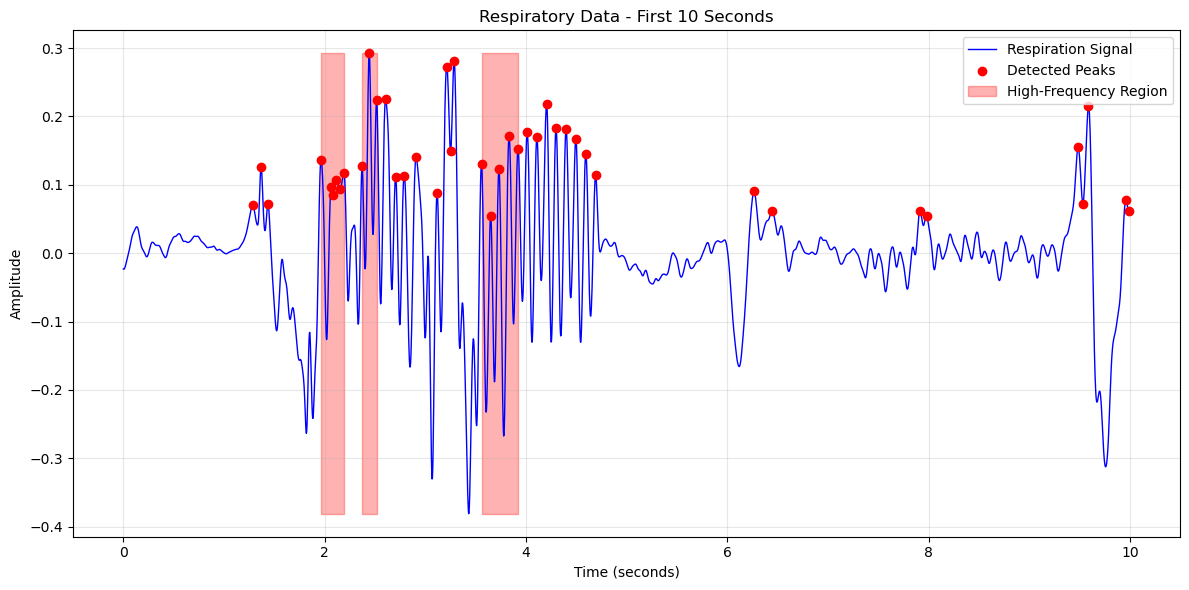

In [27]:
final_resp_plot2(resp_df, fs=fs, start_time=0, duration=10, show_peaks=True, 
                 peak_sel=0.1, peak_thresh=0.05, behavioral_data=True, show_high_freq_regions=True)
